In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from sklearn.metrics import mean_squared_error

In [2]:
!pip install openpyxl

In [3]:
csvPath = "/workspaces/codespaces-jupyter/notebooks/gwp1-q2/ukData5.xlsx"
priceCSV = pd.read_excel(csvPath, sheet_name='question2')
df = pd.DataFrame(priceCSV)

In [4]:
df

,uk6mDate,uk6mPrice,uk1Date,uk1Price,uk2Date,uk2Price,uk3Date,uk3Price,uk4Date,uk4Price,uk5Date,uk5Price,uk10Date,uk10Price,uk20Date,uk20Price,uk30Date,uk30Price
0,2025-01-21,4.592,2025-01-20,4.5505,2025-01-20,4.3985,2025-01-20,4.2255,2025-01-20,4.2665,2025-01-20,4.4225,2025-01-21,4.6635,2025-01-21,5.178,2025-01-21,5.236
1,2025-01-20,4.607,2025-01-17,4.5205,2025-01-17,4.3615,2025-01-17,4.1895,2025-01-17,4.2335,2025-01-17,4.3820,2025-01-20,4.6580,2025-01-20,5.154,2025-01-20,5.209
2,2025-01-17,4.615,2025-01-16,4.5015,2025-01-16,4.3810,2025-01-16,4.2075,2025-01-16,4.2595,2025-01-16,4.4055,2025-01-17,4.6555,2025-01-17,5.155,2025-01-17,5.210
3,2025-01-16,4.640,2025-01-15,4.5720,2025-01-15,4.4520,2025-01-15,4.2730,2025-01-15,4.3105,2025-01-15,4.4625,2025-01-16,4.6805,2025-01-16,5.183,2025-01-16,5.244
4,2025-01-15,4.634,2025-01-14,4.6595,2025-01-14,4.5885,2025-01-14,4.4085,2025-01-14,4.4600,2025-01-14,4.6120,2025-01-15,4.7305,2025-01-15,5.234,2025-01-15,5.299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,NaT,NaN,2019-08-07,0.5610,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN
1761,NaT,NaN,2019-08-06,0.5260,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN
1762,NaT,NaN,2019-08-05,0.5290,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN
1763,NaT,NaN,2019-08-02,0.5160,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN


In [17]:
# Combine all dates into a single column
all_dates = pd.concat([
    df['uk6mDate'],
    df['uk1Date'],
    df['uk2Date'],
    df['uk3Date'],
    df['uk4Date'],
    df['uk5Date'],
    df['uk10Date'],
    df['uk20Date'],
    df['uk30Date'],
]).dropna()

# Convert to datetime and create a new dataframe
all_dates = pd.to_datetime(all_dates, dayfirst=True)
final_df = pd.DataFrame(index=all_dates.unique())  # Use unique dates to avoid duplicates
final_df.sort_index(inplace=True)

# Add price columns
# Ensure all date columns are in datetime format with dayfirst=True
df['uk6mDate'] = pd.to_datetime(df['uk6mDate'], dayfirst=True)
df['uk1Date'] = pd.to_datetime(df['uk1Date'], dayfirst=True)
df['uk2Date'] = pd.to_datetime(df['uk2Date'], dayfirst=True)
df['uk3Date'] = pd.to_datetime(df['uk3Date'], dayfirst=True)
df['uk4Date'] = pd.to_datetime(df['uk4Date'], dayfirst=True)
df['uk5Date'] = pd.to_datetime(df['uk5Date'], dayfirst=True)
df['uk10Date'] = pd.to_datetime(df['uk10Date'], dayfirst=True)
df['uk20Date'] = pd.to_datetime(df['uk20Date'], dayfirst=True)
df['uk30Date'] = pd.to_datetime(df['uk30Date'], dayfirst=True)

# Map prices to the final dataframe
final_df['uk6m_price'] = final_df.index.map(dict(zip(df['uk6mDate'], df['uk6mPrice'])))
final_df['uk1_price'] = final_df.index.map(dict(zip(df['uk1Date'], df['uk1Price'])))
final_df['uk2_price'] = final_df.index.map(dict(zip(df['uk2Date'], df['uk2Price'])))
final_df['uk3_price'] = final_df.index.map(dict(zip(df['uk3Date'], df['uk3Price'])))
final_df['uk4_price'] = final_df.index.map(dict(zip(df['uk4Date'], df['uk4Price'])))
final_df['uk5_price'] = final_df.index.map(dict(zip(df['uk5Date'], df['uk5Price'])))
final_df['uk10_price'] = final_df.index.map(dict(zip(df['uk10Date'], df['uk10Price'])))
final_df['uk20_price'] = final_df.index.map(dict(zip(df['uk20Date'], df['uk20Price'])))
final_df['uk30_price'] = final_df.index.map(dict(zip(df['uk30Date'], df['uk30Price'])))
# Fill NaN values using cubic spline interpolation
for column in final_df.columns:
    final_df[column] = final_df[column].interpolate(method='cubic')  # Interpolate missing values
    final_df[column] = final_df[column].ffill()  # Forward fill remaining NaNs


In [18]:
final_df

,uk6m_price,uk1_price,uk2_price,uk3_price,uk4_price,uk5_price,uk10_price,uk20_price,uk30_price
2019-08-01,0.733,0.5270,0.4320,0.3490,0.3570,0.3690,0.5950,1.134,1.284
2019-08-02,0.739,0.5160,0.4290,0.3290,0.3320,0.3390,0.5520,1.088,1.243
2019-08-05,0.739,0.5290,0.4300,0.3180,0.3180,0.3210,0.5130,1.034,1.192
2019-08-06,0.743,0.5260,0.4290,0.3210,0.3210,0.3280,0.5140,1.032,1.191
2019-08-07,0.741,0.5610,0.4580,0.3550,0.3510,0.3380,0.4890,0.985,1.134
...,...,...,...,...,...,...,...,...,...
2025-01-15,4.634,4.5720,4.4520,4.2730,4.3105,4.4625,4.7305,5.234,5.299
2025-01-16,4.640,4.5015,4.3810,4.2075,4.2595,4.4055,4.6805,5.183,5.244
2025-01-17,4.615,4.5205,4.3615,4.1895,4.2335,4.3820,4.6555,5.155,5.210
2025-01-20,4.607,4.5505,4.3985,4.2255,4.2665,4.4225,4.6580,5.154,5.209


In [19]:
# Compute percentage change for all price columns
price_columns = ['uk6m_price','uk1_price', 'uk2_price', 'uk3_price', 'uk4_price', 'uk5_price','uk10_price','uk20_price','uk30_price']
yields_df = final_df[price_columns].pct_change().dropna()

# The new DataFrame will have the same index as final_df
print(yields_df)

            uk6m_price  uk1_price  uk2_price  uk3_price  uk4_price  uk5_price  \
2019-08-02    0.008186  -0.020873  -0.006944  -0.057307  -0.070028  -0.081301   
2019-08-05    0.000000   0.025194   0.002331  -0.033435  -0.042169  -0.053097   
2019-08-06    0.005413  -0.005671  -0.002326   0.009434   0.009434   0.021807   
2019-08-07   -0.002692   0.066540   0.067599   0.105919   0.093458   0.030488   
2019-08-08    0.010796   0.001783   0.021834   0.033803   0.042735   0.076923   
...                ...        ...        ...        ...        ...        ...   
2025-01-15   -0.018636  -0.018779  -0.029748  -0.030736  -0.033520  -0.032415   
2025-01-16    0.001295  -0.015420  -0.015948  -0.015329  -0.011832  -0.012773   
2025-01-17   -0.005388   0.004221  -0.004451  -0.004278  -0.006104  -0.005334   
2025-01-20   -0.001733   0.006636   0.008483   0.008593   0.007795   0.009242   
2025-01-21   -0.003256   0.000000   0.000000   0.000000   0.000000   0.000000   

            uk10_price  uk2

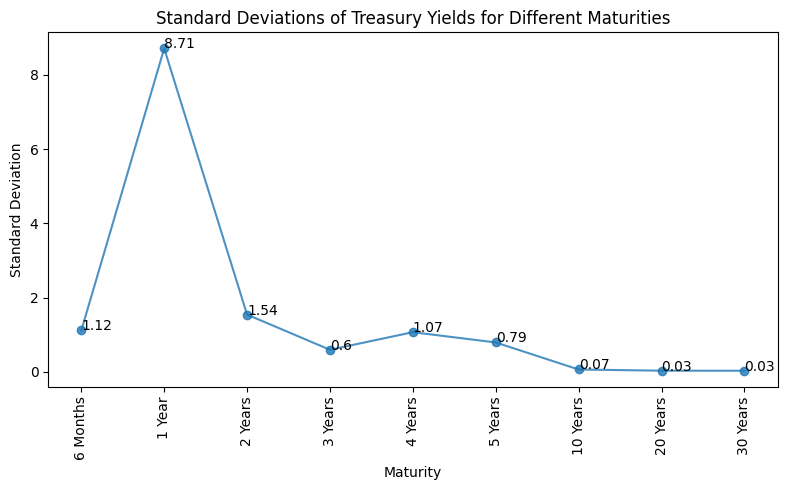

In [20]:
import matplotlib.pyplot as plt

# Calculate the standard deviation of yields
y_std = yields_df.std()

# Define custom x-axis labels
maturities = ['6 Months', '1 Year', '2 Years', '3 Years', '4 Years', '5 Years', '10 Years', '20 Years', '30 Years']

# Plot the standard deviations
fig, ax = plt.subplots(figsize=(8, 5))
y_std.plot(marker='o', title='Standard Deviations of Treasury Yields for Different Maturities', alpha=0.8)

# Add labels and annotations
plt.xlabel("Maturity")
plt.ylabel("Standard Deviation")
for i in range(len(y_std)):
    ax.annotate(str(round(y_std.iloc[i], 2)), xy=(i, y_std.iloc[i]))

# Set custom x-axis labels and rotate them vertically
plt.xticks(range(len(maturities)), maturities, rotation=90)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

Figure


/tmp/ipykernel_540/3839105374.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


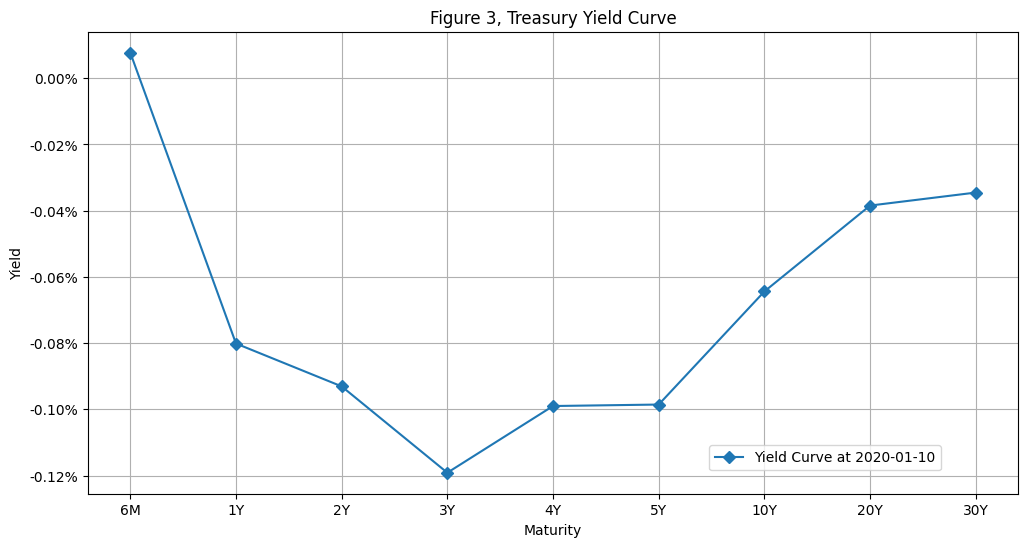

In [21]:
#First we have to plot a yield curve for a specific date
def plot_yield_curve(date, fig_n):
    maturities = ['6M', '1Y', '2Y', '3Y', '4Y', '5Y', '10Y', '20Y', '30Y'] # Maturities
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, yields_df.loc[date], marker='D', label='Yield Curve at ' + date)

    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)

    # Add labels and title
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title(fig_n+'Treasury Yield Curve')


    fig.legend(loc = [0.69, 0.14])

    # Show the plot
    plt.grid(True)
    plt.show()

print("Figure")
plot_yield_curve('2020-01-10','Figure 3, ')


In [ ]:
pip install nelson-siegel-svensson

NelsonSiegelCurve(beta0=np.float64(-0.024072638558996384), beta1=np.float64(0.1502934537663796), beta2=np.float64(-0.5108554253071206), tau=np.float64(0.9960859318893104))
Nelson-Siegel Model Parameters:
beta0 (Level): -0.024072638558996384
beta1 (Slope): 0.1502934537663796
beta2 (Curvature): -0.5108554253071206
tau (Decay rate): 0.9960859318893104
Nelson-Siegel Mean Squared Error (MSE): 8.177454639653351e-05


Text(0.5, 1.0, 'Figure , NS Model Result')

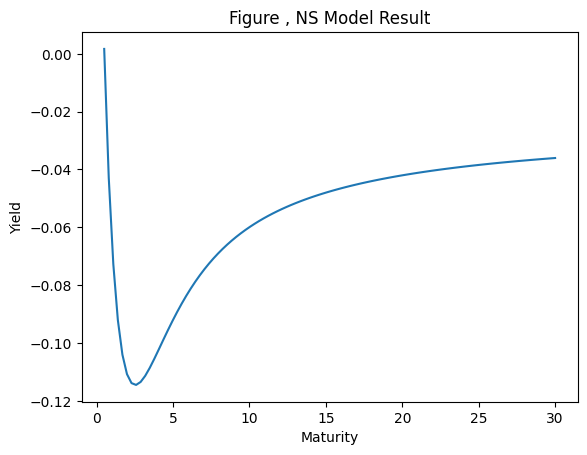

In [23]:
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
from scipy.interpolate import CubicSpline
from sklearn.metrics import mean_squared_error

# Replace these with csv file path for the UK gilt maturities and yields
#csvPath = r"C:\Users\Samuel Enyan\OneDrive\Desktop\Sam\WQU\MScFE\600 Financial Data\gwp1\ukData.csv"
#priceCSV = pd.read_csv(csvPath)
#df = pd.DataFrame(priceCSV)

# Maturities (in years) and yields (as percentages)
maturities = np.array([0.5, 1, 2, 3, 4, 5, 10, 20, 30])  # Short to long-term maturities
#yields = np.array([3.1, 3.2, 3.4, 3.5, 3.7, 3.8, 4.0, 4.5, 4.8])  # Example yields in %
y = np.array(yields_df.loc["2020-01-10"])
# --- Nelson-Siegel Model ---
# Fit the Nelson-Siegel model
curve_ns, status_ns = calibrate_ns_ols(maturities, y, tau0=1.0)  # Initial tau guess
assert status_ns.success, "Nelson-Siegel fitting failed."
print(curve_ns)

# Print Nelson-Siegel model parameters
print("Nelson-Siegel Model Parameters:")
print(f"beta0 (Level): {curve_ns.beta0}")
print(f"beta1 (Slope): {curve_ns.beta1}")
print(f"beta2 (Curvature): {curve_ns.beta2}")
print(f"tau (Decay rate): {curve_ns.tau}")

# Evaluate the Nelson-Siegel model at the original maturity points
ns_fitted_yields = curve_ns(maturities)
# Calculate MSE for Nelson-Siegel model
mse_ns = mean_squared_error(y, ns_fitted_yields)
print(f"Nelson-Siegel Mean Squared Error (MSE): {mse_ns}")

# Predicted yields from Nelson-Siegel model
#ns_fitted_yields = curve_ns(maturities)
y_hat = curve_ns
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure , NS Model Result")



In [24]:
#Now we are going for Cubic Spline model

In [25]:
yields_df.loc["2020-01-10"]

uk6m_price    0.007692
uk1_price    -0.080123
uk2_price    -0.093063
uk3_price    -0.119134
uk4_price    -0.098993
uk5_price    -0.098546
uk10_price   -0.064399
uk20_price   -0.038462
uk30_price   -0.034536
Name: 2020-01-10 00:00:00, dtype: float64

In [26]:
#t = np.array([.5,5,10,20])
#y = np.array([0.007692,-0.098546,-0.064399,-0.038462])

Mean Squared Error (MSE): 5.349805401075655e-36


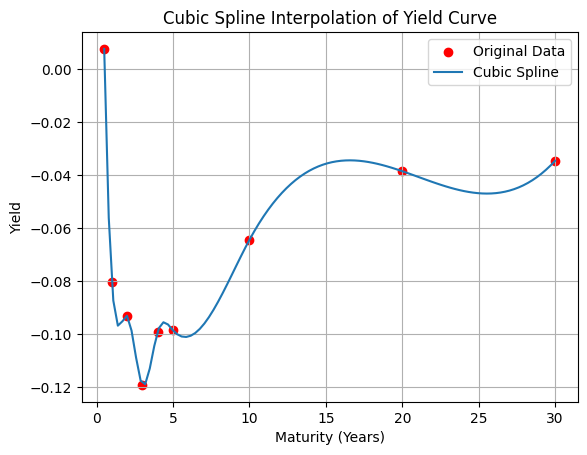

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from sklearn.metrics import mean_squared_error

# Example data with more points
t = np.array([0.5, 1, 2, 3, 4, 5, 10, 20, 30])
y = np.array([0.007692, -0.080123, -0.093063, -0.119134, -0.098993, -0.098546, -0.064399, -0.038462, -0.034536])

# Fit a cubic spline
cs = CubicSpline(t, y)

# Evaluate the spline at the original maturity points
interpolated_y_at_t = cs(t)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, interpolated_y_at_t)
print(f"Mean Squared Error (MSE): {mse}")

# Evaluate the spline at new points (e.g., for plotting)
new_t = np.linspace(0.5, 30, 100)  # 100 points between 0.5 and 30 years
interpolated_y = cs(new_t)

# Plot the original data and the cubic spline
plt.scatter(t, y, color='red', label='Original Data')
plt.plot(new_t, interpolated_y, label='Cubic Spline')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield')
plt.title('Cubic Spline Interpolation of Yield Curve')
plt.legend()
plt.grid(True)
plt.show()